## 1. 키워드 : '국내 총생산', '금리', '실업률', '고용률', '물가'
## 2. 기간 : 2008/01/01 ~ 2025/02/28
## 3. 예상 갯수
- '국내 총생산' : 약 139,000 개
- '금리' : 약 18,400,000 개
- '실업률' : 약 49,000 개
- '고용률' : 약 40,900 개
- '물가' : 약 8,460,000 개

##  구글 뉴스 웹크롤링

In [9]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity="all"

In [361]:
import requests
from bs4 import BeautifulSoup
import urllib.parse
import time
import pandas as pd
from datetime import datetime

def encode_date_range(start_date, end_date):
    # 형식: 2008-01-01 → 1/1/2008 (MM/DD/YYYY)
    start_parts = start_date.split('-')
    end_parts = end_date.split('-')
    
    # 구글 검색에서 사용하는 정확한 날짜 형식으로 변환
    start_formatted = f"{int(start_parts[1])}/{int(start_parts[2])}/{start_parts[0]}"
    end_formatted = f"{int(end_parts[1])}/{int(end_parts[2])}/{end_parts[0]}"
    
    # 전체 tbs 매개변수 구성 (중요: 날짜 필터 형식을 정확히 지정)
    date_range = f"cdr:1,cd_min:{start_formatted},cd_max:{end_formatted}"
    
    return date_range

def crawl_google_news_titles(keyword, start_date, end_date, max_pages=None): # 뉴스 제목과 날짜 추출
    date_range = encode_date_range(start_date, end_date)
    
    page = 0
    titles = []
    dates = []
    
    while max_pages is None or page < max_pages:
        # 직접 URL 구성 (tbs 매개변수 형식 유지를 위해)
        url = "https://www.google.com/search"
        params = {
            'q': keyword,
            'tbm': 'nws',  # 뉴스 검색
            'tbs': date_range,  # 날짜 범위
            'start': page * 10,  # 페이지 오프셋
        }
        
        # 최종 URL 생성
        search_url = url + '?' + '&'.join([f"{k}={urllib.parse.quote_plus(str(v))}" for k, v in params.items()])
        
        try:
            print(f"페이지 {page+1} 크롤링 중...")
            # print(f"URL: {search_url}")
            
            # User-Agent 헤더 추가하여 차단 방지
            headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
            }
            
            response = requests.get(search_url, headers=headers)
            response.raise_for_status()
            soup = BeautifulSoup(response.content, 'html.parser')
            
            # 날짜 필터가 적용되었는지 확인
            date_filter_element = soup.select_one('.hdtb-mn-hd')
            if date_filter_element:
                print(f"적용된 필터: {date_filter_element.get_text(strip=True)}")
            
            # 뉴스 아이템 컨테이너 선택
            news_items = soup.select('div.SoAPf')
            
            if not news_items:
                print(f"더 이상 결과가 없거나 태그 구조가 변경되었습니다.")
                break
                
            for item in news_items:
                # 제목 요소 선택
                title_element = item.select_one('div.n0jPhd.ynAwRc.MBeuO.nDgy9d')
                
                if title_element:
                    # 제목에서 텍스트 직접 추출
                    title_text = title_element.get_text(strip=True)
                    titles.append(title_text)
                else:
                    # 대체 선택자 시도
                    alt_title_element = item.select_one('div.MBeuO')
                    if alt_title_element:
                        titles.append(alt_title_element.get_text(strip=True))
                    else:
                        titles.append("제목 없음")
                
                # 날짜 추출
                date_element = item.select_one('div.OSrXXb.rbYSKb.LfVVr')
                if date_element:
                    dates.append(date_element.get_text(strip=True))
                else:
                    # 대체 선택자 시도
                    alt_date_element = item.select_one('span.WG9SHc')
                    if alt_date_element:
                        dates.append(alt_date_element.get_text(strip=True))
                    else:
                        dates.append("날짜 없음")
                
                # 기사 URL 추출 (원본 링크 확인용)
                # link_element = item.select_one('a')
                # if link_element and 'href' in link_element.attrs:
                #     link = link_element['href']
                #     if link.startswith('/url?'):
                #         # Google의 리다이렉트 URL에서 실제 URL 추출
                #         parsed_url = urllib.parse.urlparse(link)
                #         url_params = urllib.parse.parse_qs(parsed_url.query)
                #         if 'url' in url_params:
                #             urls.append(url_params['url'][0])
                #         else:
                #             urls.append(link)
                #     else:
                #         urls.append(link)
                # else:
                #     urls.append("")
            
            print(f"페이지 {page+1} 크롤링 완료 ({len(news_items)}개 뉴스)")
            
            # 다음 페이지 버튼 확인
            next_button = soup.select_one('#pnnext')
            if not next_button:
                print("마지막 페이지에 도달했습니다.")
                break
                
            page += 1
            time.sleep(2)  # 구글 차단 방지를 위한 딜레이
            
        except requests.exceptions.RequestException as e:
            print(f"오류 발생: {e}")
            break
    
    # 데이터프레임 생성
    df = pd.DataFrame({
        '제목': titles,
        '날짜': dates
    })
    
    # 현재 검색 정보 추가
    df['검색어'] = keyword
    df['검색기간'] = f"{start_date} ~ {end_date}"
    df['수집일시'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    
    return df

def save_to_csv(df, keyword, start_date, end_date):
    """데이터프레임을 CSV 파일로 저장합니다."""
    filename = f"{keyword}_{start_date}_{end_date}.csv"
    df.to_csv(f'./data/구글 뉴스 제목/{keyword}/{filename}', index=False, encoding='utf-8-sig')
    print(f"결과가 {filename} 파일로 저장되었습니다.")
    return filename

def verify_date_range(df, start_year, end_year):
    """날짜 범위가 적절하게 적용되었는지 확인합니다."""
    
    # 날짜 열에서 연도 추출 시도
    year_pattern = r'(\d{4})년'
    
    # 연도가 있는 항목 수 확인
    years_found = df['날짜'].str.extract(year_pattern, expand=False).dropna()
    
    # 연도 범위 확인
    years_found = years_found.astype(int)
    if years_found.min() < start_year or years_found.max() > end_year:
        print(f"경고: 검색 결과에 지정한 연도 범위({start_year}-{end_year}) 밖의 기사가 포함되어 있습니다.")
        print(f"발견된 연도 범위: {years_found.min()}-{years_found.max()}")
        return False
    
    print(f"날짜 범위 확인 완료: 모든 결과가 {start_year}-{end_year} 범위 내에 있습니다.")
    return True

# 사용
if __name__ == "__main__":
    # 변수 설정
    keyword = "고용률"
    start_date = "2009-01-01"
    end_date = "2009-06-30"
    max_pages = None 
    
    # 연도 추출
    start_year = int(start_date.split('-')[0])
    end_year = int(end_date.split('-')[0])
    
    # 크롤링 및 결과 저장
    print(f"키워드: {keyword}, 기간: {start_date} ~ {end_date}")
    print(f"검색 필터: {encode_date_range(start_date, end_date)}")
    
    df = crawl_google_news_titles(keyword, start_date, end_date, max_pages)
    
    # 결과 확인 및 저장
    print(f"\n총 {len(df)}개의 뉴스 제목이 수집되었습니다.")
    if len(df) > 0:
        print("\n== 데이터프레임 미리보기 ==")
        df.head(10)
        
        # 날짜 범위 검증
        if verify_date_range(df, start_year, end_year):
            # CSV 파일로 저장
            save_to_csv(df, keyword, start_date, end_date)
        else:
            save_anyway = input("\n문제가 있지만 데이터를 CSV로 저장하시겠습니까? (y/n): ")
            if save_anyway.lower() == 'y':
                save_to_csv(df, keyword, start_date, end_date)
    else:
        print("수집된 데이터가 없습니다.")

키워드: 고용률, 기간: 2009-01-01 ~ 2009-06-30
검색 필터: cdr:1,cd_min:1/1/2009,cd_max:6/30/2009
페이지 1 크롤링 중...
페이지 1 크롤링 완료 (4개 뉴스)
마지막 페이지에 도달했습니다.

총 4개의 뉴스 제목이 수집되었습니다.

== 데이터프레임 미리보기 ==


,제목,날짜,검색어,검색기간,수집일시
0,20代 남녀 고용역전 심화…여성이 1.4%P 더 높아,2009. 4. 22.,고용률,2009-01-01 ~ 2009-06-30,2025-03-25 13:30:40
1,'고용 쇼크' 1월 취업자 10.3만명 감소,2009. 2. 11.,고용률,2009-01-01 ~ 2009-06-30,2025-03-25 13:30:40
2,고용지표로 보니 美경제 이미 공황,2009. 4. 10.,고용률,2009-01-01 ~ 2009-06-30,2025-03-25 13:30:40
3,"'프리터족', 늙어간다",2009. 5. 18.,고용률,2009-01-01 ~ 2009-06-30,2025-03-25 13:30:40


날짜 범위 확인 완료: 모든 결과가 2009-2009 범위 내에 있습니다.
결과가 고용률_2009-01-01_2009-06-30.csv 파일로 저장되었습니다.


'고용률_2009-01-01_2009-06-30.csv'

In [397]:
# 최근 데이터(2025년 1, 2월)는 날짜가 '예시: 1개월 전'으로 추출되고, 기사량이 많기 때문에 크롤링이 막힘
# 범위를 지정해주면, 하루를 검색기간으로 설정해 크롤링한 후 날짜를 검색기간으로 수정 및 csv파일로 저장한 뒤
# 범위기간이 끝날때까지 하루씩 다음날로 넘어가는 것으로 자동화
import requests
from bs4 import BeautifulSoup
import urllib.parse
import time
import pandas as pd
from datetime import datetime, timedelta
import os

def encode_date_range(start_date, end_date):
    """날짜 범위를 URL 인코딩합니다. (수정된 방식)"""
    # 형식: 2008-01-01 → 1/1/2008 (MM/DD/YYYY)
    start_parts = start_date.split('-')
    end_parts = end_date.split('-')
    
    # 구글 검색에서 사용하는 정확한 날짜 형식으로 변환
    start_formatted = f"{int(start_parts[1])}/{int(start_parts[2])}/{start_parts[0]}"
    end_formatted = f"{int(end_parts[1])}/{int(end_parts[2])}/{end_parts[0]}"
    
    # 전체 tbs 매개변수 구성 (중요: 날짜 필터 형식을 정확히 지정)
    date_range = f"cdr:1,cd_min:{start_formatted},cd_max:{end_formatted}"
    
    return date_range

def crawl_google_news_titles(keyword, start_date, end_date, max_pages=None):
    """Google 뉴스에서 제목과 날짜를 추출하고 DataFrame으로 저장합니다."""
    date_range = encode_date_range(start_date, end_date)
    
    page = 0
    titles = []
    dates = []
    
    while max_pages is None or page < max_pages:
        # 직접 URL 구성 (tbs 매개변수 형식 유지를 위해)
        url = "https://www.google.com/search"
        params = {
            'q': keyword,
            'tbm': 'nws',  # 뉴스 검색
            'tbs': date_range,  # 날짜 범위
            'start': page * 10,  # 페이지 오프셋
        }
        
        # 최종 URL 생성
        search_url = url + '?' + '&'.join([f"{k}={urllib.parse.quote_plus(str(v))}" for k, v in params.items()])
        
        try:
            print(f"페이지 {page+1} 크롤링 중...")
            # print(f"URL: {search_url}")
            
            # User-Agent 헤더 추가하여 차단 방지
            headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
            }
            
            response = requests.get(search_url, headers=headers)
            response.raise_for_status()
            soup = BeautifulSoup(response.content, 'html.parser')
            
            # 날짜 필터가 적용되었는지 확인
            date_filter_element = soup.select_one('.hdtb-mn-hd')
            if date_filter_element:
                print(f"적용된 필터: {date_filter_element.get_text(strip=True)}")
            
            # 뉴스 아이템 컨테이너 선택
            news_items = soup.select('div.SoAPf')
            
            if not news_items:
                print(f"더 이상 결과가 없거나 태그 구조가 변경되었습니다.")
                break
                
            for item in news_items:
                # 제목 요소 선택
                title_element = item.select_one('div.n0jPhd.ynAwRc.MBeuO.nDgy9d')
                
                if title_element:
                    # 제목에서 텍스트 직접 추출
                    title_text = title_element.get_text(strip=True)
                    titles.append(title_text)
                else:
                    # 대체 선택자 시도
                    alt_title_element = item.select_one('div.MBeuO')
                    if alt_title_element:
                        titles.append(alt_title_element.get_text(strip=True))
                    else:
                        titles.append("제목 없음")
                
                # 날짜 추출
                date_element = item.select_one('div.OSrXXb.rbYSKb.LfVVr')
                if date_element:
                    dates.append(date_element.get_text(strip=True))
                else:
                    # 대체 선택자 시도
                    alt_date_element = item.select_one('span.WG9SHc')
                    if alt_date_element:
                        dates.append(alt_date_element.get_text(strip=True))
                    else:
                        dates.append("날짜 없음")
            
            print(f"페이지 {page+1} 크롤링 완료 ({len(news_items)}개 뉴스)")
            
            # 다음 페이지 버튼 확인
            next_button = soup.select_one('#pnnext')
            if not next_button:
                print("마지막 페이지에 도달했습니다.")
                break
                
            page += 1
            time.sleep(2)  # 구글 차단 방지를 위한 딜레이
            
        except requests.exceptions.RequestException as e:
            print(f"오류 발생: {e}")
            break
    
    # 데이터프레임 생성
    df = pd.DataFrame({
        '제목': titles,
        '날짜_원본': dates,  # 원본 날짜 저장
    })
    
    # 현재 검색 정보 추가
    df['검색어'] = keyword
    df['검색기간'] = f"{start_date} ~ {end_date}"
    df['수집일시'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    
    # 검색 날짜를 '날짜' 열로 추가 (YYYY. M. D. 형식)
    formatted_date = datetime.strptime(start_date, "%Y-%m-%d").strftime("%Y. %m. %d.")
    df['날짜'] = formatted_date
    
    return df

def save_to_csv(df, keyword, start_date, end_date, base_dir='./data/구글 뉴스 제목'):
    """데이터프레임을 CSV 파일로 저장합니다."""
    # 디렉토리 생성
    save_dir = f'{base_dir}/{keyword}/2025'
    os.makedirs(save_dir, exist_ok=True)
    
    filename = f"{keyword}_{start_date}_{end_date}.csv"
    file_path = f'{save_dir}/{filename}'
    df.to_csv(file_path, index=False, encoding='utf-8-sig')
    print(f"결과가 {file_path} 파일로 저장되었습니다.")
    return filename

def generate_date_range(start_date_str, end_date_str):
    """
    시작 날짜부터 종료 날짜까지의 날짜 목록을 생성합니다.
    각 날짜는 "YYYY-MM-DD" 형식의 문자열로 반환됩니다.
    """
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    date_list = []
    current_date = start_date
    
    while current_date <= end_date:
        date_list.append(current_date.strftime("%Y-%m-%d"))
        current_date += timedelta(days=1)
    
    return date_list

# 메인 실행 부분
if __name__ == "__main__":
    # 변수 설정
    keyword = "실업률"
    
    # 날짜 범위 설정
    date_range_start = "2025-02-15"
    date_range_end = "2025-02-28"
    
    # 날짜 목록 생성
    date_list = generate_date_range(date_range_start, date_range_end)
    
    # 각 날짜별로 크롤링 수행
    for current_date in date_list:
        print(f"\n{'=' * 50}")
        print(f"날짜 {current_date} 크롤링 시작")
        print(f"{'=' * 50}")
        
        # 해당 일자에 대해서만 크롤링 (시작일 = 종료일)
        start_date = current_date
        end_date = current_date
        max_pages = None  # 페이지 수 제한 (None = 모든 페이지)
        
        # 크롤링 및 결과 저장
        print(f"키워드: {keyword}, 기간: {start_date} ~ {end_date}")
        print(f"검색 필터: {encode_date_range(start_date, end_date)}")
        
        df = crawl_google_news_titles(keyword, start_date, end_date, max_pages)
        
        # 결과 확인 및 저장
        print(f"\n총 {len(df)}개의 뉴스 제목이 수집되었습니다.")
        if len(df) > 0:
            print("\n== 데이터프레임 미리보기 ==")
            df.head(5)
            
            # CSV 파일로 저장
            save_to_csv(df, keyword, start_date, end_date)
        else:
            print("수집된 데이터가 없습니다.")
        
        # 서버 부하 방지를 위한 대기 시간
        wait_time = 50  # 초
        print(f"\n다음 날짜 크롤링을 위해 {wait_time}초 대기 중...")
        time.sleep(wait_time)
    
    print(f"\n{'=' * 50}")
    print(f"모든 날짜({date_range_start}부터 {date_range_end}까지)의 크롤링이 완료되었습니다.")
    print(f"{'=' * 50}")


날짜 2025-02-15 크롤링 시작
키워드: 실업률, 기간: 2025-02-15 ~ 2025-02-15
검색 필터: cdr:1,cd_min:2/15/2025,cd_max:2/15/2025
페이지 1 크롤링 중...
페이지 1 크롤링 완료 (8개 뉴스)
마지막 페이지에 도달했습니다.

총 8개의 뉴스 제목이 수집되었습니다.

== 데이터프레임 미리보기 ==


,제목,날짜_원본,검색어,검색기간,수집일시,날짜
0,[그래픽] 체감실업률·'쉬었음' 청년 추이,1개월 전,실업률,2025-02-15 ~ 2025-02-15,2025-03-25 15:35:51,2025. 02. 15.
1,'1월 기준 역대 최대' 경남 고용률 61.7%…실업률 '전국 최저',1개월 전,실업률,2025-02-15 ~ 2025-02-15,2025-03-25 15:35:51,2025. 02. 15.
2,청년 고용한파 굳어지나…체감실업률·고용률 4년만에 최대 악화,1개월 전,실업률,2025-02-15 ~ 2025-02-15,2025-03-25 15:35:51,2025. 02. 15.
3,"통계청, '2025년 1월 고용동향' 발표… 청년 고용률 9개월 연속 하락",1개월 전,실업률,2025-02-15 ~ 2025-02-15,2025-03-25 15:35:51,2025. 02. 15.
4,청년층의 심각해진 고용절벽…청년층 취업자 4년만에 최대 감소,1개월 전,실업률,2025-02-15 ~ 2025-02-15,2025-03-25 15:35:51,2025. 02. 15.


결과가 ./data/구글 뉴스 제목/실업률/2025/실업률_2025-02-15_2025-02-15.csv 파일로 저장되었습니다.


'실업률_2025-02-15_2025-02-15.csv'


다음 날짜 크롤링을 위해 50초 대기 중...

날짜 2025-02-16 크롤링 시작
키워드: 실업률, 기간: 2025-02-16 ~ 2025-02-16
검색 필터: cdr:1,cd_min:2/16/2025,cd_max:2/16/2025
페이지 1 크롤링 중...
페이지 1 크롤링 완료 (10개 뉴스)
페이지 2 크롤링 중...
페이지 2 크롤링 완료 (10개 뉴스)
페이지 3 크롤링 중...
페이지 3 크롤링 완료 (10개 뉴스)
페이지 4 크롤링 중...
페이지 4 크롤링 완료 (8개 뉴스)
마지막 페이지에 도달했습니다.

총 38개의 뉴스 제목이 수집되었습니다.

== 데이터프레임 미리보기 ==


...


다음 날짜 크롤링을 위해 50초 대기 중...

날짜 2025-02-28 크롤링 시작
키워드: 실업률, 기간: 2025-02-28 ~ 2025-02-28
검색 필터: cdr:1,cd_min:2/28/2025,cd_max:2/28/2025
페이지 1 크롤링 중...
페이지 1 크롤링 완료 (5개 뉴스)
마지막 페이지에 도달했습니다.

총 5개의 뉴스 제목이 수집되었습니다.

== 데이터프레임 미리보기 ==


,제목,날짜_원본,검색어,검색기간,수집일시,날짜
0,[이슈분석] 실업률에 집중한 시장…연준 금리 입장 변화 가능성은?,3주 전,실업률,2025-02-28 ~ 2025-02-28,2025-03-25 15:47:09,2025. 02. 28.
1,"[이슈] ""날씨가 내 월급까지 결정한다고?""...기후변화가 내 노동환경을 바꾼다",3주 전,실업률,2025-02-28 ~ 2025-02-28,2025-03-25 15:47:09,2025. 02. 28.
2,"DOGE의 구조조정, 실업수당 청구건수 증가의 배경?",3주 전,실업률,2025-02-28 ~ 2025-02-28,2025-03-25 15:47:09,2025. 02. 28.
3,미국 경제 성장 엔진에 이상 신호...믿었던 고용 시장마저,3주 전,실업률,2025-02-28 ~ 2025-02-28,2025-03-25 15:47:09,2025. 02. 28.
4,[자막뉴스] 연준이 두려워하는 시그널...쓰나미 몰려온 미국,3주 전,실업률,2025-02-28 ~ 2025-02-28,2025-03-25 15:47:09,2025. 02. 28.


결과가 ./data/구글 뉴스 제목/실업률/2025/실업률_2025-02-28_2025-02-28.csv 파일로 저장되었습니다.


'실업률_2025-02-28_2025-02-28.csv'


다음 날짜 크롤링을 위해 50초 대기 중...

모든 날짜(2025-02-15부터 2025-02-28까지)의 크롤링이 완료되었습니다.


## 데이터 병합 및 중복 제거

In [158]:
keyword = '금리'

In [399]:
# 키워드 별로 데이터 합치기
import pandas as pd
import glob
import os

# CSV 파일이 있는 폴더 경로 지정
folder_path = f'./data/구글 뉴스 제목/{keyword}/2025'  # 실제 폴더 경로로 변경해주세요

# 모든 CSV 파일 경로 가져오기
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

# 빈 리스트 생성 (각 CSV 파일을 DataFrame으로 저장할 리스트)
dataframes_list = []

# 각 CSV 파일을 읽어서 리스트에 추가
for csv_file in csv_files:
    # CSV 파일 읽기
    df_temp = pd.read_csv(csv_file, encoding='utf-8-sig')
    # 리스트에 추가
    dataframes_list.append(df_temp)  

# 모든 DataFrame을 하나로 결합
if dataframes_list:
    df = pd.concat(dataframes_list, ignore_index=True)
    df = df.reindex(columns=['제목', '날짜', '검색어', '검색기간', '수집일시','날짜_원본'])
    df.drop('날짜_원본', axis=1, inplace=True)
    print(f"병합 전 총 행 수: {len(df)}")
    df.drop_duplicates(subset='제목', inplace=True)
    print(f"중복 제거 후 총 행 수: {len(df)}")
    df.dropna(inplace=True)
    print(f"결측치 제거 후 총 행 수: {len(df)}")
    df.to_csv(f'./data/구글 뉴스 제목/{keyword}/{keyword}_2025-01-01_2025-02-28.csv', index=False, encoding='utf-8')
    print(f"\n모든 CSV 파일 결합 완료. 총 행 수: {len(df)}")

병합 전 총 행 수: 460
중복 제거 후 총 행 수: 437
결측치 제거 후 총 행 수: 437

모든 CSV 파일 결합 완료. 총 행 수: 437


In [173]:
os.path.exists(folder_path)

True

In [1]:
# 키워드 별로 데이터 합치기
import pandas as pd
import glob
import os

# CSV 파일이 있는 폴더 경로 지정
folder_path = f'./data/구글 뉴스 제목'  # 실제 폴더 경로로 변경해주세요

# 모든 CSV 파일 경로 가져오기
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

# 빈 리스트 생성 (각 CSV 파일을 DataFrame으로 저장할 리스트)
dataframes_list = []

# 각 CSV 파일을 읽어서 리스트에 추가
for csv_file in csv_files:
    # CSV 파일 읽기
    df_temp = pd.read_csv(csv_file, encoding='utf-8-sig')
    # 리스트에 추가
    dataframes_list.append(df_temp)  

# 모든 DataFrame을 하나로 결합
if dataframes_list:
    df = pd.concat(dataframes_list, ignore_index=True)
    print(f"병합 전 총 행 수: {len(df)}")
    df.drop_duplicates(subset='제목', inplace=True)
    print(f"중복 제거 후 총 행 수: {len(df)}")
    df = df.drop(df.columns[5:], axis=1)
    df.dropna(inplace=True)
    print(f"결측치 제거 후 총 행 수: {len(df)}")
    df.to_csv(
        f'./data/구글 뉴스 제목/all_news_2008-01-01_2025-02-28.csv',
        index=False,
        encoding='utf-8-sig'
    )
    print(f"\n모든 CSV 파일 결합 완료. 총 행 수: {len(df)}")
else:
    print("오류: 병합할 CSV 파일이 없습니다.")

병합 전 총 행 수: 69142
중복 제거 후 총 행 수: 66924
결측치 제거 후 총 행 수: 66924

모든 CSV 파일 결합 완료. 총 행 수: 66924


In [389]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7153 entries, 0 to 7152
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   제목      7153 non-null   object        
 1   날짜      7153 non-null   datetime64[ns]
 2   검색어     7153 non-null   object        
 3   검색기간    7153 non-null   object        
 4   수집일시    7153 non-null   object        
 5   연도      7153 non-null   int32         
 6   월       7153 non-null   int32         
dtypes: datetime64[ns](1), int32(2), object(4)
memory usage: 335.4+ KB


In [282]:
df.to_csv('./data/구글 뉴스 제목/금리_2008-01-01_2024-12-31.csv', index=False, encoding='utf-8-sig')

## 시각화 해서 수집한 데이터 분포 확인

In [31]:
import matplotlib.pyplot as plt
font_path = 'C:\\WINDOWS\\Fonts\\NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

In [19]:
keyword = '통합'

In [21]:
import pandas as pd
df = pd.read_csv(f'./data/구글 뉴스 제목/{keyword}_2008-01-01_2025-02-28.csv') 
df.head()

,제목,날짜,검색어,검색기간,수집일시
0,20대 남·여 고용률 첫 역전…여성이 1.2%P 앞서 59.4%,2008. 4. 20.,고용률,2008-01-01 ~ 2008-06-30,2025-03-21 09:49:43
1,"""대졸 별볼일 없네""..고용률 OECD 최하위권",2008. 6. 19.,고용률,2008-01-01 ~ 2008-06-30,2025-03-21 09:49:43
2,20대 남성 ‘눈높이 낮추느니 차라리 백수’,2008. 4. 21.,고용률,2008-01-01 ~ 2008-06-30,2025-03-21 09:49:43
3,[건국 60주년 한국경제 어제와 오늘] 고용과 실업,2008. 6. 12.,고용률,2008-01-01 ~ 2008-06-30,2025-03-21 09:49:43
4,1분기 인구이동 3.2% 감소,2008. 5. 21.,고용률,2008-01-01 ~ 2008-06-30,2025-03-21 09:49:43


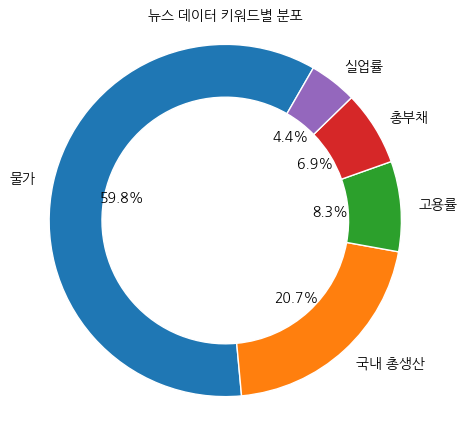

In [43]:
# '키워드' 열로 그룹화하여 개수 세기
keyword_counts = df['검색어'].value_counts()

# 도넛 그래프 그리기
plt.figure(figsize=(5, 5))
plt.pie(keyword_counts,
        labels=keyword_counts.index,
        autopct='%1.1f%%',
        startangle=60,
        wedgeprops={'width': 0.3, 'edgecolor': 'white'})  # wedgeprops로 도넛 모양 설정
plt.title('뉴스 데이터 키워드별 분포', fontproperties=fontprop)
plt.axis('equal')  # 원이 찌그러지지 않도록 설정
plt.show()

<Figure size 2000x800 with 0 Axes>

<BarContainer object of 12 artists>

<BarContainer object of 12 artists>

<BarContainer object of 12 artists>

<BarContainer object of 12 artists>

...

<BarContainer object of 2 artists>

Text(0.5, 1.0, '구글 경제 뉴스 월별 분포 (2008-2025)')

Text(0.5, 0, '날짜')

Text(0, 0.5, '데이터 개수')

C:\Users\jioyu\AppData\Local\Temp\ipykernel_27492\2927832718.py:58: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jioyu\AppData\Local\Temp\ipykernel_27492\2927832718.py:61: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) Arial.
  plt.savefig(f'./graph/{keyword}_데이터 분포_bar.png', dpi=300, bbox_inches='tight')
C:\Anaconda3\envs\NLPenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


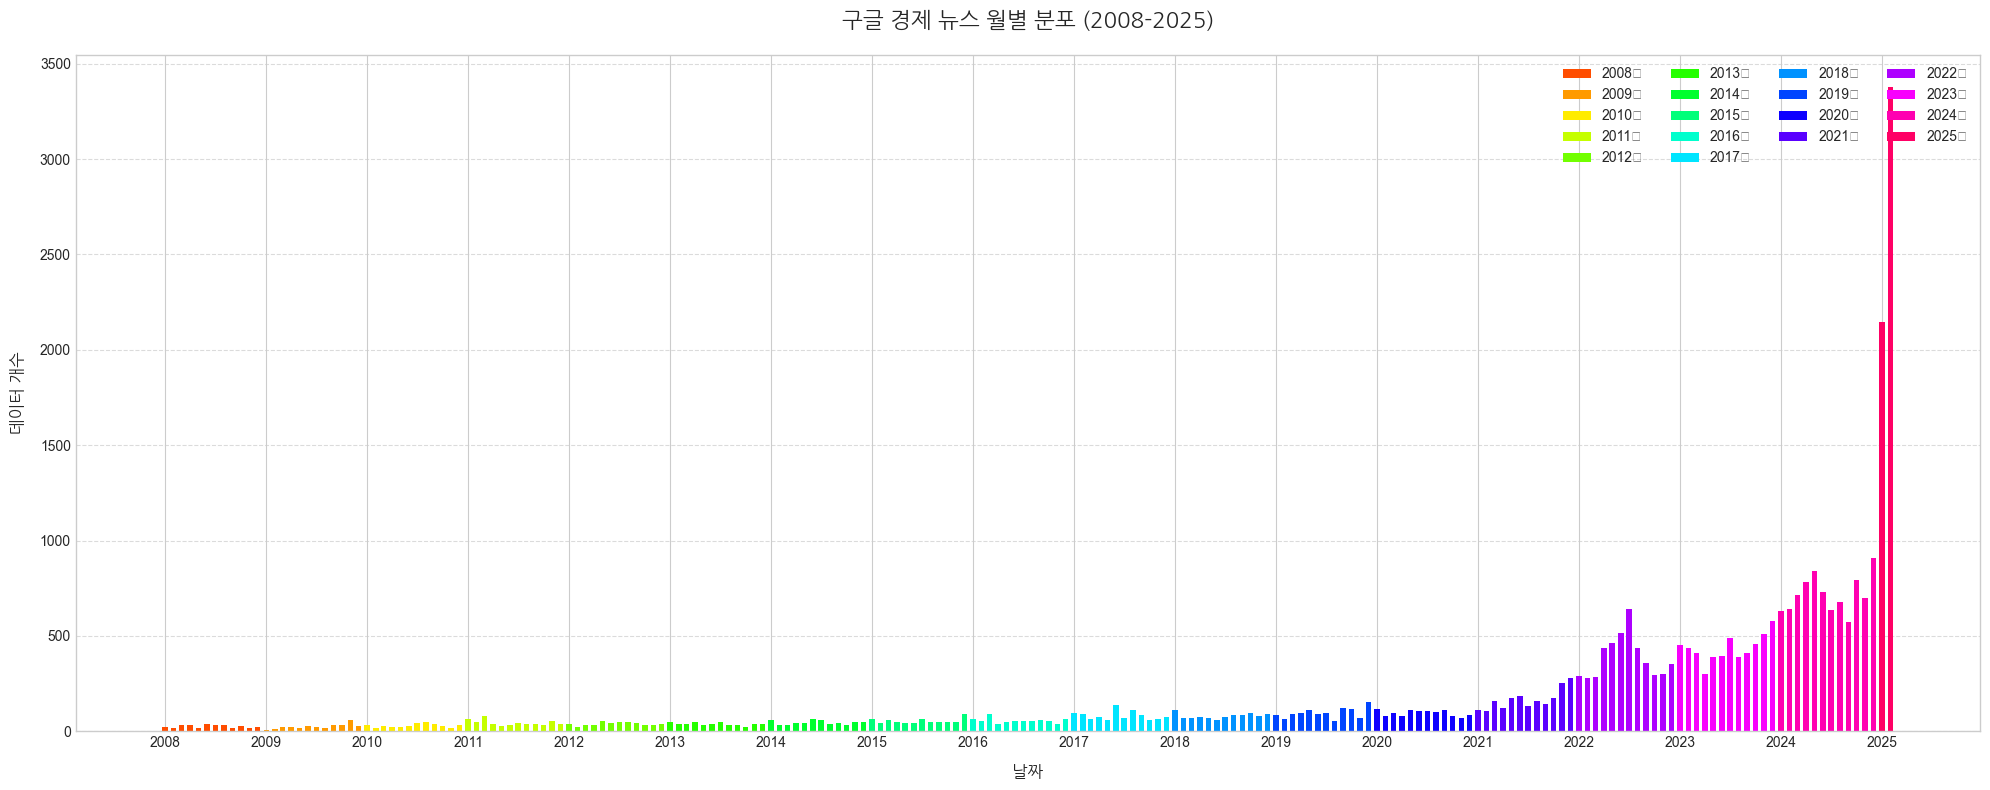

In [15]:
# 월별 뉴스 개수 확인 (python)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns

# 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")

# 날짜 데이터가 '2008.1.1.' 형태로 저장되어 있다고 가정
df = pd.read_csv(f'./data/구글 뉴스 제목/{keyword}_2008-01-01_2025-02-28.csv')  # 실제 데이터 파일 불러오기
df['날짜'] = pd.to_datetime(df['날짜'], format='%Y. %m. %d.')

# 연도와 월 추출
df['연도'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month

# 연도-월별 데이터 개수 집계
monthly_counts = df.groupby(['연도', '월']).size().reset_index(name='count')

# 날짜 열 생성 (연도-월을 datetime으로 변환)
monthly_counts['date'] = pd.to_datetime(monthly_counts['연도'].astype(str) + '-' + monthly_counts['월'].astype(str) + '-01')
monthly_counts = monthly_counts.sort_values('date')

# 1. 막대그래프
plt.figure(figsize=(20, 8), dpi=100)

# 연도별로 다른 색상 사용
years = monthly_counts['연도'].unique()
palette = sns.color_palette("hsv", len(years))
year_colors = dict(zip(years, palette))

# 연도별 색상으로 막대 그래프 그리기
for year in years:
    year_data = monthly_counts[monthly_counts['연도'] == year]
    plt.bar(year_data['date'], year_data['count'], width=20, 
            label=f'{year}년', color=year_colors[year])

# 범례 추가
plt.legend(loc='upper right', ncol=4)

# x축 날짜 형식 설정
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())

# 그래프 제목 및 레이블 설정
plt.title(f'구글 경제 뉴스 월별 분포 (2008-2025)', fontproperties=fontprop, fontsize=16, pad=20)
plt.xlabel('날짜', fontproperties=fontprop, fontsize=12, labelpad=10)
plt.ylabel('데이터 개수', fontproperties=fontprop, fontsize=12, labelpad=10)

# 그리드 설정
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 여백 조정
plt.tight_layout()

# 그래프 저장 (선택사항)
plt.savefig(f'./graph/{keyword}_데이터 분포_bar.png', dpi=300, bbox_inches='tight')

# 그래프 표시
plt.show()

<Figure size 1600x800 with 0 Axes>

<Axes: xlabel='연도', ylabel='월'>

Text(0.5, 1.0, '구글 경제 뉴스 월별 분포 (2008-2025)')

Text(0.5, 63.583333333333314, '연도')

Text(175.58333333333334, 0.5, '월')

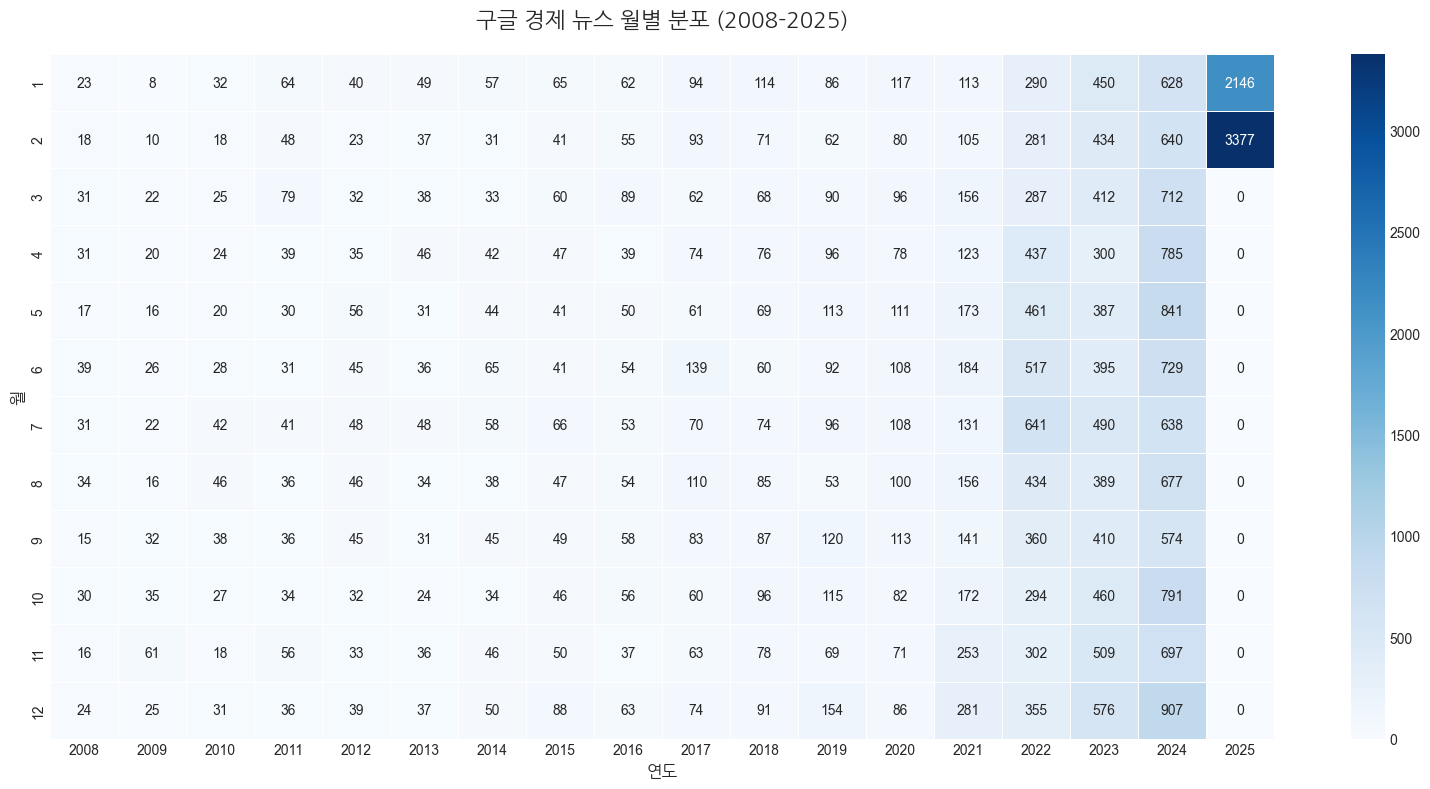

In [16]:
# 2. 히트맵
# pivot_table 사용 (더 간단한 방법)
pivot_data = pd.pivot_table(monthly_counts, values='count', 
                            index='월', columns='연도', 
                            fill_value=0)  # 누락된 값을 0으로 채움

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_data, cmap='Blues', annot=True, fmt='.0f', linewidths=.5)

plt.title(f'구글 경제 뉴스 월별 분포 (2008-2025)', fontproperties=fontprop, fontsize=16, pad=20)
plt.xlabel('연도', fontproperties=fontprop, fontsize=12)
plt.ylabel('월', fontproperties=fontprop, fontsize=12)

plt.tight_layout()
plt.savefig(f'./graph/{keyword}_데이터 분포_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()